In [7]:
import geometric_predict
import cv2
from matplotlib import pyplot as plt
import numpy as np

In [ ]:
INTERNAL_CROP_RECT = (900, 540, 380, 240) # User confirmed crop bounds

alum_img_path = "./images/test_images/aluminum_1.jpg"
glass_img_path = "./images/test_images/success_7.jpg"

img_alum = cv2.imread(alum_img_path)
img_glass = cv2.imread(glass_img_path)

In [26]:
alum_bound, glass_bound, deterministic_decision = geometric_predict.predict_single_static(img_alum, img_glass, INTERNAL_CROP_RECT, 90., 3.)
print("Deterministic decision: ", deterministic_decision)

Deterministic decision:  True


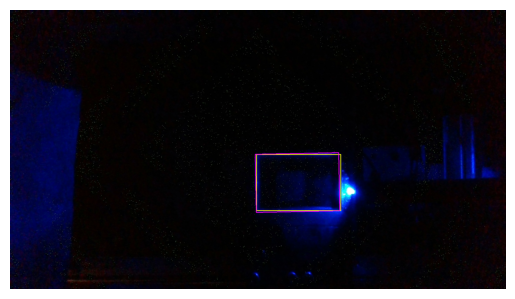

In [ ]:
alum_bound = alum_bound[0]
glass_bound = glass_bound[0]
# draw aluminum rectangle
cv2.rectangle(img_glass,
              (INTERNAL_CROP_RECT[0] + alum_bound[0][0], INTERNAL_CROP_RECT[1] + alum_bound[0][1]),
              (INTERNAL_CROP_RECT[0] + alum_bound[2][0], INTERNAL_CROP_RECT[1] + alum_bound[2][1]),
              (0, 255, 255), 2)

# draw glass rectangle
box = glass_bound.reshape((-1, 1, 2)).astype(np.int32)
off_x = INTERNAL_CROP_RECT[0]
off_y = INTERNAL_CROP_RECT[1]

box_offset = box + [off_x, off_y]
cv2.drawContours(img_glass, [box_offset], 0, (255, 0,255), 2)

# Show the frame
img_rgb = cv2.cvtColor(img_glass, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()